# 08 — Catálogo de algoritmos y evidencia comparativa

> **Catálogo homogéneo `showcase_master_catalog.json`** — mismos SKUs P1–P5 en 3D-BPP, Container Loading y Single Container. Cada tipo usa una **instancia showcase** compleja donde el benchmark **diferencia** los algoritmos del grupo.

| Grupo benchmark | Instancia | Diferenciación esperada |
|-----------------|-----------|-------------------------|
| 3D-BPP | `showcase_3d_bpp_instance.json` | best_fit ~27 emp. vs extreme_points ~22 |
| Híbrido (misma instancia 3D) | `showcase_3d_bpp_instance.json` | compaction/LS mueven 8–11 piezas |
| Mejora 3D (misma instancia 3D) | `showcase_3d_bpp_instance.json` | relocation/swap/orientation/bin_reduction refinan layout |
| Container Loading | `showcase_container_loading_instance.json` | weight_aware ~27 vs single_container ~17 |
| Single Container | `showcase_single_container_instance.json` | best_fit ~13 (94% util) vs first_fit ~16 |
| Cartonization | `showcase_cartonization_instance.json` | single-box vs multi_box |
| Palletization | `showcase_palletization_instance.json` | layer_based vs stack_based |
| Stacking-aware | `showcase_stacking_aware_instance.json` | stacking_aware vs stack_based |

Catálogo de **29 algoritmos implementados**, cada uno con endpoint propio ``POST /api/v1/algorithms/{name}/execute`` y **9 grupos de benchmark**. Adaptador ``py3dbp`` activo si la dependencia está instalada.


In [1]:
# Configuración del entorno (ejecutar primero)
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _nb = _candidate / "notebooks"
    if (_nb / "_shared" / "loaders.py").exists():
        if str(_nb) not in sys.path:
            sys.path.insert(0, str(_nb))
        break
else:
    raise RuntimeError("No se encontró notebooks/_shared. Abre el notebook desde packing-services/.")

from _shared.loaders import setup_paths
ROOT = setup_paths(_cwd)
from _shared import display, viz, runners

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"Proyecto: {ROOT}")


Proyecto: /home/edmundo/packing-services


In [2]:
from packing_services.algorithms.registry import get_default_registry
from packing_services.domain.enums import AlgorithmStatus
from _shared.loaders import BENCHMARK_GROUPS
import pandas as pd
from IPython.display import display as ipy_display

registry = get_default_registry()
from packing_services.services.algorithm_input_service import AlgorithmInputService
input_svc = AlgorithmInputService(registry)
impl = registry.list_metadata(status=AlgorithmStatus.IMPLEMENTED)
rows = [{'Algoritmo': m.name, 'Familia': m.algorithm_family.value,
         'Problemas': ', '.join(p.value for p in m.problem_types),
         'Input': input_svc.input_schema_for(m),
         'Endpoint': input_svc.execution_endpoint(m.name)} for m in impl]
ipy_display(pd.DataFrame(rows).style.hide(axis='index'))


Algoritmo,Familia,Problemas,Input,Endpoint
aco_3d_bpp,metaheuristic,3D_BPP,PackAlgorithmInput,POST /api/v1/algorithms/aco_3d_bpp/execute
best_box_volume_utilization,constructive_heuristic,CARTONIZATION,CartonizationAlgorithmInput,POST /api/v1/algorithms/best_box_volume_utilization/execute
best_fit_decreasing_3d,constructive_heuristic,"3D_BPP, SINGLE_CONTAINER_LOADING",PackAlgorithmInput,POST /api/v1/algorithms/best_fit_decreasing_3d/execute
bin_reduction,improvement_heuristic,"3D_BPP, CONTAINER_LOADING",PackAlgorithmInput,POST /api/v1/algorithms/bin_reduction/execute
constructive_plus_local_search,hybrid,"3D_BPP, CONTAINER_LOADING",PackAlgorithmInput,POST /api/v1/algorithms/constructive_plus_local_search/execute
extreme_points_3d,constructive_heuristic,"3D_BPP, CONTAINER_LOADING",PackAlgorithmInput,POST /api/v1/algorithms/extreme_points_3d/execute
first_fit_box,constructive_heuristic,CARTONIZATION,CartonizationAlgorithmInput,POST /api/v1/algorithms/first_fit_box/execute
first_fit_decreasing_3d,constructive_heuristic,"3D_BPP, SINGLE_CONTAINER_LOADING",PackAlgorithmInput,POST /api/v1/algorithms/first_fit_decreasing_3d/execute
genetic_algorithm_3d_bpp,metaheuristic,3D_BPP,PackAlgorithmInput,POST /api/v1/algorithms/genetic_algorithm_3d_bpp/execute
grasp_3d_bpp,metaheuristic,3D_BPP,PackAlgorithmInput,POST /api/v1/algorithms/grasp_3d_bpp/execute


In [3]:
print('═══ Demo: ejecutar un algoritmo vía servicio propio ═══')
from _shared.loaders import build_algorithm_execute_input
demo_algo = 'extreme_points_3d'
payload = build_algorithm_execute_input(demo_algo, problem_type='3D_BPP')
print(f'POST /api/v1/algorithms/{demo_algo}/execute')
display.show_execute_result(runners.run_algorithm_execute(demo_algo, payload))


2026-07-13 12:46:46,560 | INFO    | packing_services.services.algorithm_execution_service | algorithm-execute name=extreme_points_3d problem_type=3D_BPP request_id=showcase-3d-bpp-001


2026-07-13 12:46:46,561 | INFO    | packing_services.services.packing_service | pack request_id=showcase-3d-bpp-001 algorithm=extreme_points_3d items=30 containers=2


2026-07-13 12:46:46,581 | INFO    | packing_services.services.packing_service | pack done request_id=showcase-3d-bpp-001 status=SolutionStatus.PARTIAL packed=22 unpacked=8 util=0.657


═══ Demo: ejecutar un algoritmo vía servicio propio ═══
POST /api/v1/algorithms/extreme_points_3d/execute


PackingSolution(request_id='showcase-3d-bpp-001', status=<SolutionStatus.PARTIAL: 'partial'>, problem_type=<ProblemType.THREE_D_BPP: '3D_BPP'>, algorithm_name='extreme_points_3d', packed_items=[PackedItem(item_id='P2#1', container_id='C1', position=Point3D(x=0.0, y=0.0, z=0.0), orientation=Orientation(length=60.0, width=30.0, height=40.0), weight=7.0), PackedItem(item_id='P2#2', container_id='C2', position=Point3D(x=0.0, y=0.0, z=0.0), orientation=Orientation(length=60.0, width=30.0, height=40.0), weight=7.0), PackedItem(item_id='P2#3', container_id='C1', position=Point3D(x=60.0, y=0.0, z=0.0), orientation=Orientation(length=30.0, width=60.0, height=40.0), weight=7.0), PackedItem(item_id='P2#4', container_id='C2', position=Point3D(x=60.0, y=0.0, z=0.0), orientation=Orientation(length=30.0, width=60.0, height=40.0), weight=7.0), PackedItem(item_id='P2#5', container_id='C1', position=Point3D(x=0.0, y=30.0, z=0.0), orientation=Orientation(length=60.0, width=30.0, height=40.0), weight=7.0)

═══ Evidencia comparativa: 9 benchmarks homogéneos ═══
Motores comparables — 3D Bin Packing:


#,Algoritmo,Nombre,Opcional
1,heuristic_3d_bpp_v1,Volume First Candidate Placement,No
2,first_fit_decreasing_3d,First Fit Decreasing 3D,No
3,extreme_points_3d,Extreme Points Heuristic,No
4,best_fit_decreasing_3d,Best Fit Decreasing 3D,No
5,maximal_spaces_3d,Maximal Empty Spaces 3D,No
6,py3dbp_adapter,py3dbp Adapter (baseline externo),Sí


Nota: best_fit ~27 emp. (85% util) vs extreme_points ~22 (66%)
Benchmark — 3D Bin Packing


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,best_fit_decreasing_3d,84.8%,27,3,Sí,0.0307
2,first_fit_decreasing_3d,78.3%,25,5,Sí,0.0091
3,heuristic_3d_bpp_v1,78.3%,25,5,Sí,0.0105
4,py3dbp_adapter,78.3%,25,5,Sí,0.0148
5,maximal_spaces_3d,70.4%,23,7,Sí,0.0058
6,extreme_points_3d,65.7%,22,8,Sí,0.0158


Ranking 3D-BPP: (1) soluciones válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor containers_used; (5) menor tiempo.


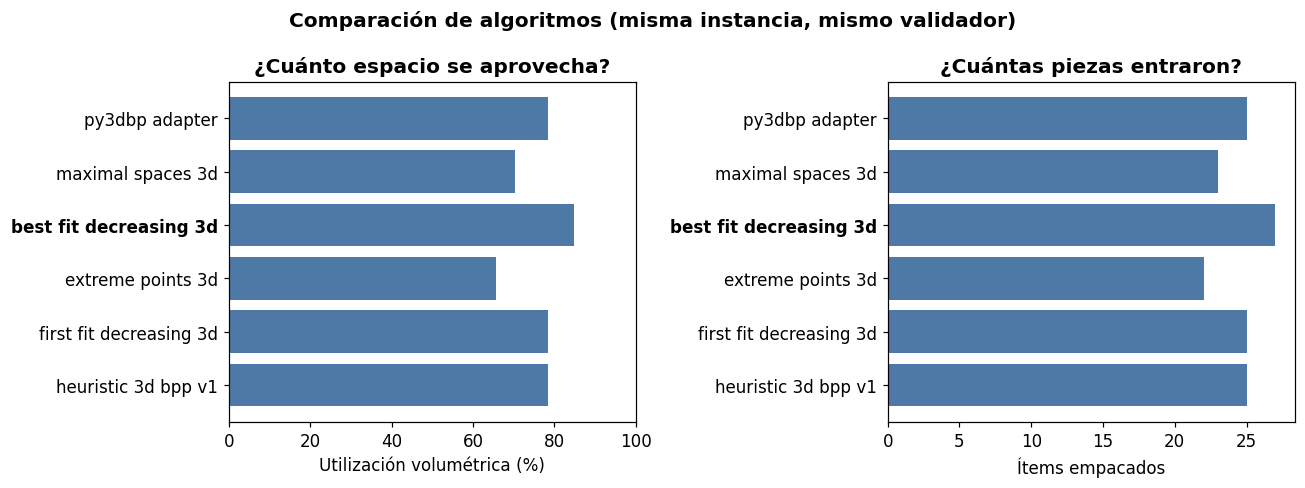

Motores comparables — 3D Bin Packing — Constructivo + mejora local:


#,Algoritmo,Nombre,Opcional
1,best_fit_decreasing_3d,Best Fit Decreasing 3D (baseline),No
2,solution_compaction,Compaction (mejora local),No
3,constructive_plus_local_search,Constructive + Local Improvement,No


Nota: misma cantidad empacada; compaction/LS mueven 8–11 piezas


Benchmark — 3D Bin Packing — Constructivo + mejora local


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s),Piezas movidas
1,best_fit_decreasing_3d,84.8%,27,3,Sí,0.0369,nan
2,solution_compaction,84.8%,27,3,Sí,0.1283,8.000000
3,constructive_plus_local_search,84.8%,27,3,Sí,0.2177,11.000000


Ranking 3D-BPP: (1) soluciones válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor containers_used; (5) menor tiempo.


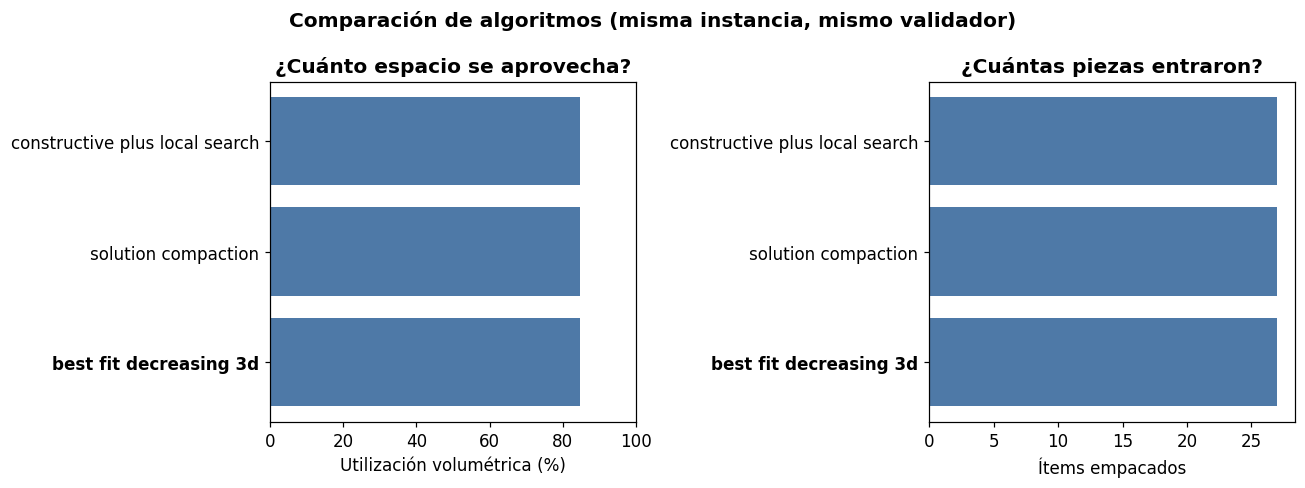

Motores comparables — 3D Bin Packing — Mejora local extendida:


#,Algoritmo,Nombre,Opcional
1,best_fit_decreasing_3d,Best Fit Decreasing 3D (baseline),No
2,relocation_improvement,Relocation Improvement,No
3,swap_improvement,Swap Improvement,No
4,orientation_improvement,Orientation Improvement,No
5,bin_reduction,Bin Reduction,No


Nota: misma baseline; relocation/swap/orientation/bin_reduction refinan layout


Benchmark — 3D Bin Packing — Mejora local extendida


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s),Piezas movidas
1,best_fit_decreasing_3d,84.8%,27,3,Sí,0.0331,nan
2,orientation_improvement,84.8%,27,3,Sí,0.0362,0.000000
3,swap_improvement,84.8%,27,3,Sí,0.0522,0.000000
4,relocation_improvement,84.8%,27,3,Sí,0.2416,11.000000


Ranking 3D-BPP: (1) soluciones válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor containers_used; (5) menor tiempo.


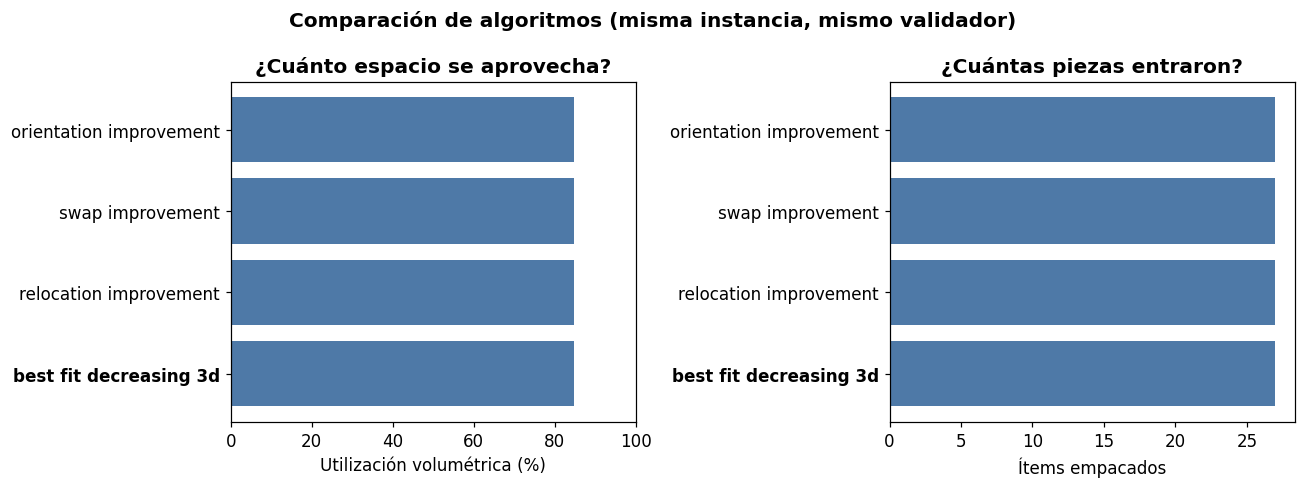

Motores comparables — 3D Bin Packing — Metaheurísticas:


#,Algoritmo,Nombre,Opcional
1,best_fit_decreasing_3d,Best Fit Decreasing 3D (baseline),No
2,simulated_annealing_3d_bpp,Simulated Annealing,No
3,grasp_3d_bpp,GRASP,No
4,lns_3d_bpp,Large Neighborhood Search,No


Nota: metaheurísticas optimizan orden de colocación sobre baseline constructivo


Benchmark — 3D Bin Packing — Metaheurísticas


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,simulated_annealing_3d_bpp,91.2%,29,1,Sí,0.7246
2,grasp_3d_bpp,91.2%,29,1,Sí,17.9060
3,lns_3d_bpp,86.5%,28,2,Sí,0.5147
4,best_fit_decreasing_3d,84.8%,27,3,Sí,0.0325


Ranking 3D-BPP: (1) soluciones válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor containers_used; (5) menor tiempo.


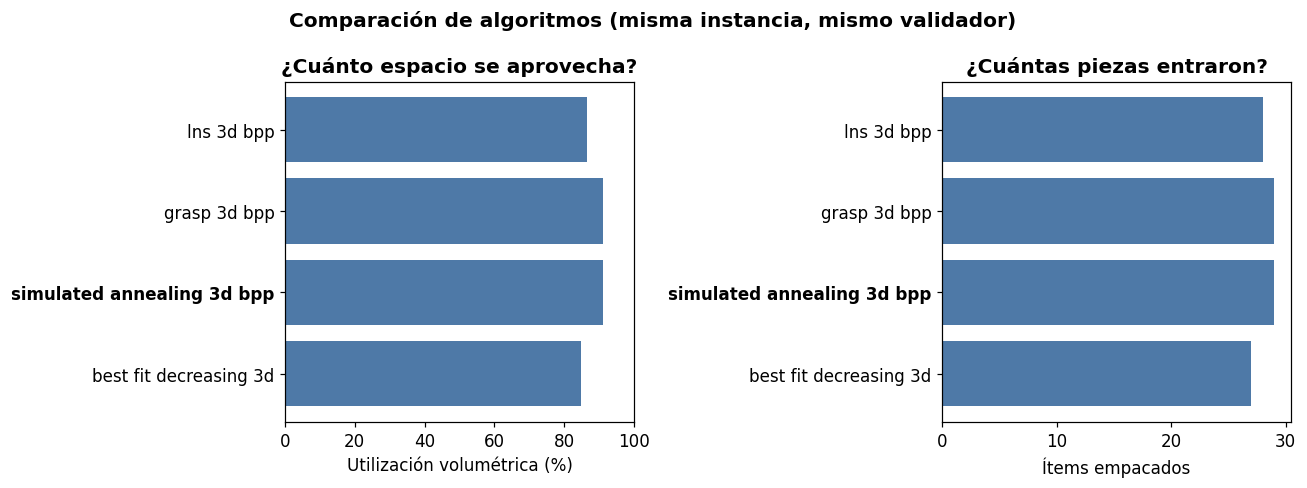

Motores comparables — Container Loading:


#,Algoritmo,Nombre,Opcional
1,single_container_constructive,Single Container Constructive,No
2,weight_aware_container_loading,Weight-aware Container Loading,No
3,wall_building_3d,Wall-building Heuristic,No
4,extreme_points_3d,Extreme Points (multi-contenedor),No


2026-07-13 12:47:05,789 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=single_container_constructive items=30 containers=2


2026-07-13 12:47:05,806 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=weight_aware_container_loading items=30 containers=2


2026-07-13 12:47:05,843 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=wall_building_3d items=30 containers=2


2026-07-13 12:47:05,853 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=extreme_points_3d items=30 containers=2


Nota: weight_aware ~27 emp. vs wall_building ~24 vs single_container ~17
Benchmark — Container Loading


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,weight_aware_container_loading,84.8%,27,3,Sí,0.0337
2,extreme_points_3d,65.7%,22,8,Sí,0.0175
3,single_container_constructive,87.5%,17,13,Sí,0.0150
4,wall_building_3d,22.5%,4,26,Sí,0.0085


Ranking Container Loading: (1) válidas; (2) menor items_unpacked; (3) mayor volume_utilization; (4) menor tiempo.


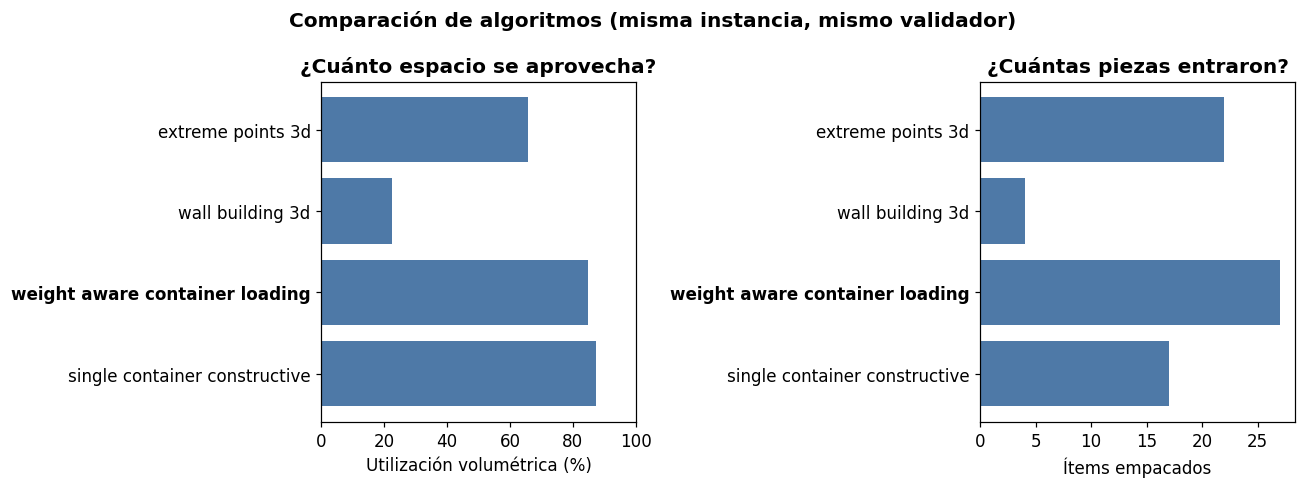

Motores comparables — Cartonization:


#,Algoritmo,Nombre,Opcional
1,smallest_feasible_box,Smallest Feasible Box,No
2,best_box_volume_utilization,Best Box by Volume Utilization,No
3,first_fit_box,First Fit Box (orden catálogo),No
4,largest_feasible_box,Largest Feasible Box,No
5,multi_box_cartonization,Multi-box Cartonization,No


2026-07-13 12:47:06,154 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=smallest_feasible_box items=6 boxes=3


2026-07-13 12:47:06,163 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=best_box_volume_utilization items=6 boxes=3


2026-07-13 12:47:06,174 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=first_fit_box items=6 boxes=3


2026-07-13 12:47:06,182 | INFO    | packing_services.services.cartonization_service | cartonization request_id=benchmark-carton-001 algorithm=largest_feasible_box items=6 boxes=3


Nota: single-box → BOX_M (~49%) vs multi_box → varias cajas S/M
Benchmark — Cartonization


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s),Caja elegida
1,first_fit_box,48.5%,6,0,Sí,0.0029,BOX_M
2,smallest_feasible_box,48.5%,6,0,Sí,0.0034,BOX_M
3,best_box_volume_utilization,48.5%,6,0,Sí,0.0054,BOX_M
4,largest_feasible_box,20.8%,6,0,Sí,0.0025,BOX_L


Ranking Cartonization: (1) válidas; (2) todos los ítems empacados; (3) mayor volume_utilization; (4) menor tiempo.


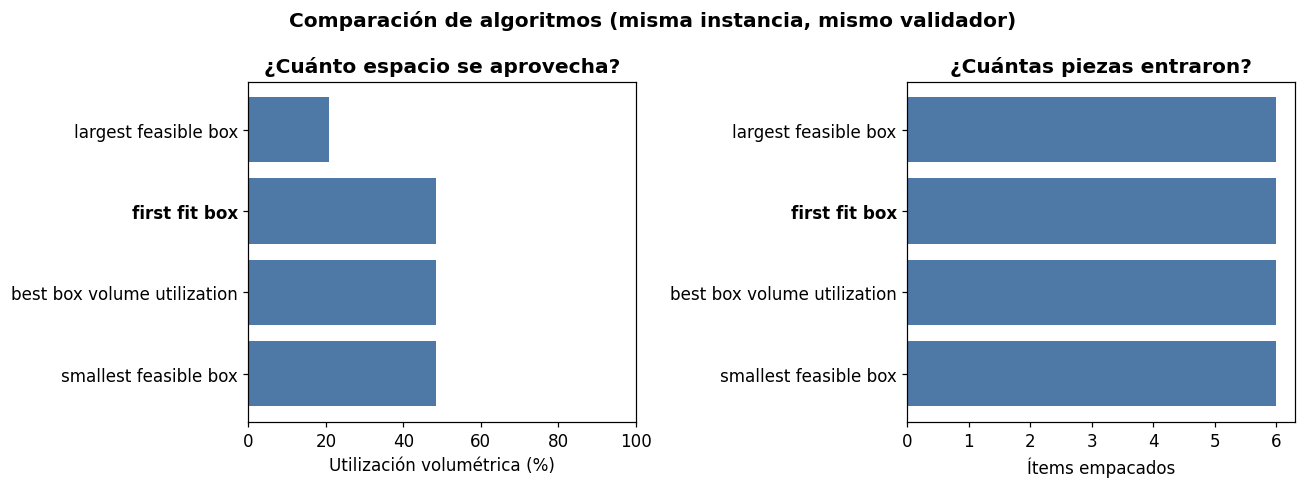

Motores comparables — Single Container Loading:


#,Algoritmo,Nombre,Opcional
1,single_container_constructive,Single Container Constructive,No
2,best_fit_decreasing_3d,Best Fit Decreasing 3D,No
3,first_fit_decreasing_3d,First Fit Decreasing 3D,No


Nota: best_fit/single ~13 emp. (94% util) vs first_fit ~16 (89%)
Benchmark — Single Container Loading


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,single_container_constructive,94.3%,13,17,Sí,0.0109
2,best_fit_decreasing_3d,94.3%,13,17,Sí,0.0115
3,first_fit_decreasing_3d,89.3%,16,14,Sí,0.0055


Ranking Single Container Loading: (1) válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor tiempo.


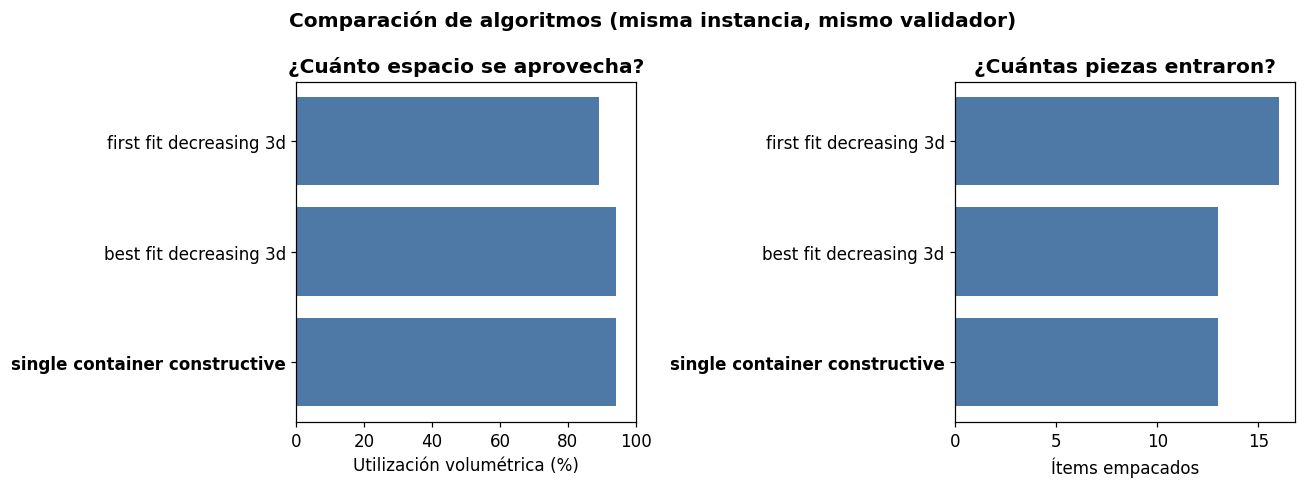

Motores comparables — Palletization:


#,Algoritmo,Nombre,Opcional
1,layer_based_palletization,Layer-based Palletization,No
2,stack_based_palletization,Stack-based Palletization,No


Nota: layer_based ~capas horizontales vs stack_based ~columnas
Benchmark — Palletization


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,layer_based_palletization,22.2%,11,0,Sí,0.0060
2,stack_based_palletization,22.2%,11,0,Sí,0.0132


Ranking Palletization: (1) válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor tiempo.


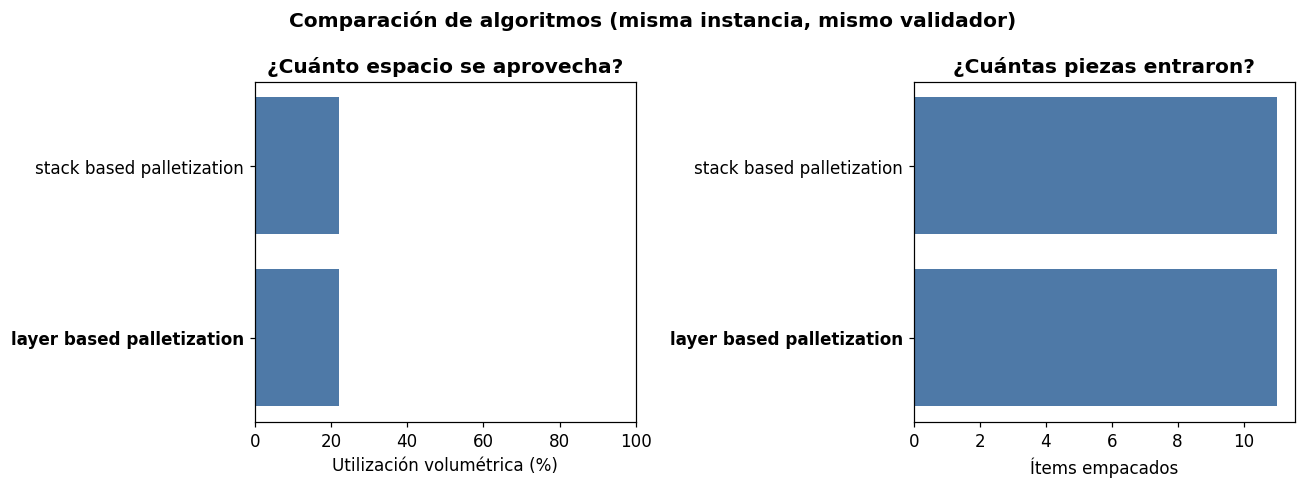

Motores comparables — Stacking-aware Packing:


#,Algoritmo,Nombre,Opcional
1,stacking_aware_constructive,Stacking-aware Constructive,No
2,stack_based_palletization,Stack-based (sin reglas de apilamiento),No


Nota: stacking_aware respeta soporte/carga vs stack_based libre
Benchmark — Stacking-aware Packing


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,stack_based_palletization,16.5%,6,0,Sí,0.0037
2,stacking_aware_constructive,16.5%,6,0,Sí,0.0044


Ranking Stacking-aware: (1) válidas; (2) menor items_unpacked; (3) mayor volume_utilization; (4) menor tiempo.


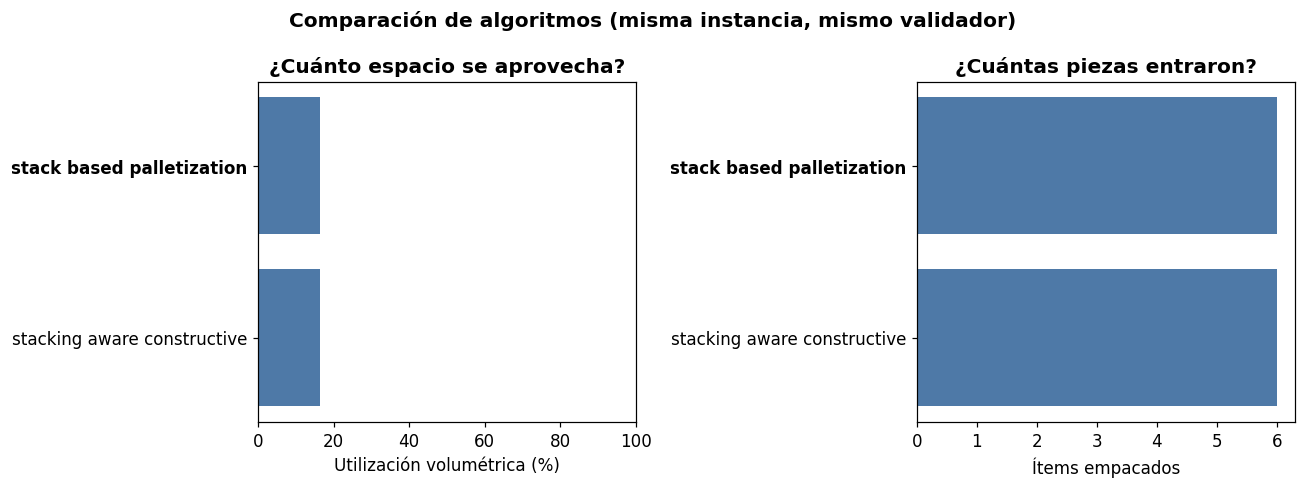

In [4]:
print('═══ Evidencia comparativa: 9 benchmarks homogéneos ═══')
for group in BENCHMARK_GROUPS:
    display.run_and_show_showcase_benchmark(group)


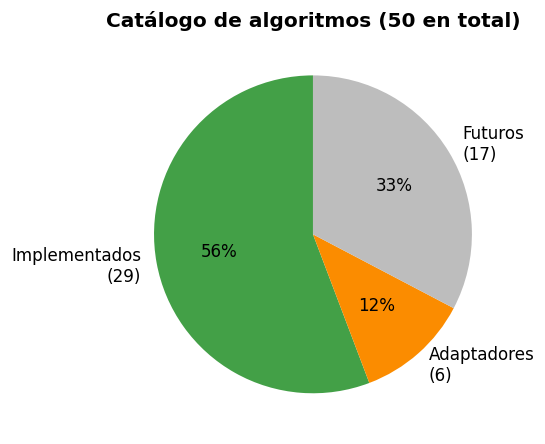

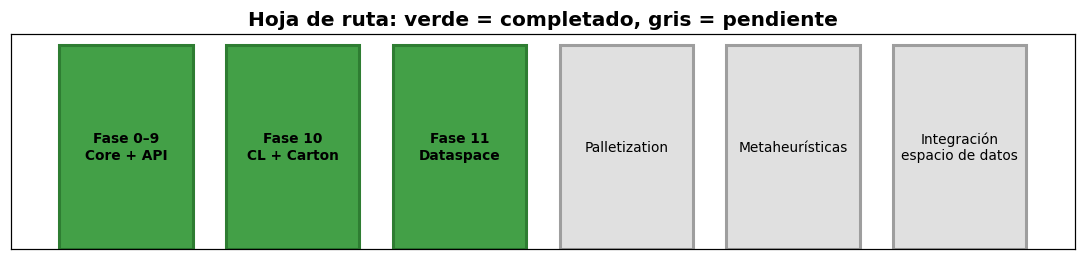

In [5]:
by = {}
for m in registry.list_metadata(): by[m.status.value] = by.get(m.status.value, 0) + 1
fig = viz.plot_algorithm_catalog_counts(by.get('implemented', 0), by.get('adapter', 0), by.get('future', 0))
plt.show()
fig = viz.plot_roadmap_phases(); plt.show()


**Siguiente:** `09_preparacion_espacio_de_datos.ipynb`
